# 🔤 Distorted Text Recognition with Deep Learning

**Competition:** CIG AI/ML Problem Statement  
**Task:** Read text from distorted, noisy grayscale images  
**Metric:** Character Error Rate (CER) — lower is better  
**Model:** CNN + BiLSTM + CTC (CRNN architecture)

---

### How this notebook is structured

| Section | What it does |
|---|---|
| 1. Imports | Load all required libraries |
| 2. Config | Set paths, image size, training settings |
| 3. Vocabulary | Map characters ↔ numbers for the model |
| 4. Dataset | Load images and labels from disk |
| 5. Augmentation | Make training images harder so the model generalises |
| 6. DataLoaders | Batch the data for training |
| 7. EDA | Explore the dataset visually |
| 8. Model | Build the CRNN neural network |
| 9. Loss | CTC loss — works without character-level alignment |
| 10. CER | Measure how wrong predictions are |
| 11. Training | Train the model, save the best version |
| 12. Curves | Plot loss and CER over epochs |
| 13. Evaluate | Load the best model and see predictions |
| 14. Submission | Run on test images, save CSV |
| 15. Rename | Rename the file with your name and enroll number |
| 16. Beam Search | (Optional) Better decoding than greedy |
| 17. Experiments | Ideas for improvement |
| 18. Summary | Key decisions and takeaways |


## 1. Imports & Setup

We import all the libraries we need up front.  
After that we fix a **random seed** (42) so results are reproducible — every run gives the same train/val split and weight initialisation.  
Finally, we pick the **device**: GPU (`cuda`) if available, otherwise CPU.


In [14]:
# ── Standard library ──────────────────────────────────────────────────────
import os
import random
import string
import re
from pathlib import Path

# ── Numeric / data ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Image handling ─────────────────────────────────────────────────────────
from PIL import Image, ImageFilter

# ── PyTorch ────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

# ── torchvision (image transforms) ─────────────────────────────────────────
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision.models import resnet18

# ── Training helpers ───────────────────────────────────────────────────────
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

# ── Visualisation / progress ───────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm

# ── Reproducibility: fix all random seeds ──────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Device ─────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")


Using device: cuda
PyTorch version: 2.10.0+cu128


## 2. Global Configuration

All the settings for the experiment live here — change them in one place and everything updates automatically.

- **Paths** — where images and CSVs are stored  
- **Image size** — the model always receives 32×128 pixels  
- **Vocabulary** — A-Z and 0-9 (36 characters). Index 0 is reserved as the CTC blank token  
- **Hyperparameters** — batch size, learning rate, epochs, etc.


In [15]:
# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR      = Path("dataset")        # root folder containing all data
TRAIN_IMG_DIR = DATA_DIR / "train"     # folder with training images
TEST_IMG_DIR  = DATA_DIR / "test"      # folder with test images
TRAIN_CSV     = DATA_DIR / "train.csv" # CSV with columns: image, label
OUTPUT_DIR    = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)        # create outputs/ if it doesn't exist

# ── Image dimensions ────────────────────────────────────────────────────────
# Every image is resized to exactly these dimensions before entering the model.
IMG_HEIGHT   = 32    # height in pixels
IMG_WIDTH    = 128   # width in pixels
IMG_CHANNELS = 1     # grayscale (1 channel)

# ── Character vocabulary ────────────────────────────────────────────────────
# The model predicts one of these 36 characters (or a special CTC blank).
CHARS     = string.ascii_uppercase + string.digits   # 'ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
BLANK_IDX = 0                                        # index 0 = CTC blank (do not change)
CHAR2IDX  = {ch: i + 1 for i, ch in enumerate(CHARS)}  # character → index (1-indexed)
IDX2CHAR  = {v: k for k, v in CHAR2IDX.items()}         # index → character
NUM_CLASSES = len(CHARS) + 1   # 37 total (36 chars + 1 blank)

print(f"Vocabulary size (including blank): {NUM_CLASSES}")
print(f"Characters: {CHARS}")

# ── Training hyperparameters ────────────────────────────────────────────────
BATCH_SIZE   = 32
NUM_EPOCHS   = 50
LR           = 1e-3      # ← raised from 3e-4; CTC needs a higher initial LR
WEIGHT_DECAY = 1e-4
VAL_SPLIT    = 0.15
PATIENCE     = 10

# ── Model architecture settings ─────────────────────────────────────────────
HIDDEN_SIZE    = 256
NUM_LSTM_LAYERS = 2
DROPOUT        = 0.3


Vocabulary size (including blank): 37
Characters: ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789


## 3. Vocabulary & Encoding Utilities

The model works with **numbers**, not characters.  
These two helper functions convert back and forth:

- `encode_label("AXU323")` → `[1, 24, 21, ...]` (a tensor of indices)  
- `decode_prediction([1, 24, 21, ...])` → `"AXU323"`

The **CTC greedy decode** rule: collapse runs of the same token, then remove blank tokens.  
Example: `[A, A, _, X, X, U]` → collapse → `[A, _, X, U]` → remove blanks → `"AXU"`


In [16]:
def encode_label(text: str) -> torch.LongTensor:
    """Convert a label string to a tensor of integer indices."""
    text = text.upper()
    return torch.LongTensor([CHAR2IDX[ch] for ch in text if ch in CHAR2IDX])


def decode_prediction(indices) -> str:
    """
    CTC greedy decode:
      1. Collapse repeated consecutive tokens.
      2. Remove blank tokens (index 0).
    """
    prev = None
    decoded = []
    for idx in indices:
        idx = int(idx)
        if idx != prev:                        # new token (not a repeat)
            if idx != BLANK_IDX:               # skip blank
                decoded.append(IDX2CHAR.get(idx, ""))
            prev = idx
    return "".join(decoded)


def batch_decode(log_probs) -> list:
    """
    Greedy decode a whole batch at once.
    log_probs shape: (T, B, C)  —  time steps × batch × classes
    Returns a list of decoded strings, one per image in the batch.
    """
    pred_indices = log_probs.argmax(dim=2)    # pick most likely class at each timestep → (T, B)
    pred_indices = pred_indices.permute(1, 0) # → (B, T)
    return [decode_prediction(row.cpu().numpy()) for row in pred_indices]


# ── Sanity check: encode then decode should give back the original string ───
sample_text = "AXU323"
enc = encode_label(sample_text)
dec = decode_prediction(enc.numpy())
print(f"Encode → Decode: '{sample_text}' → {enc.tolist()} → '{dec}'")
assert dec == sample_text, "Round-trip failed!"
print("Round-trip test passed ✓")


Encode → Decode: 'AXU323' → [1, 24, 21, 30, 29, 30] → 'AXU323'
Round-trip test passed ✓


## 4. Dataset & Data Loading

Two `Dataset` classes:

- **`CaptchaDataset`** — used for training and validation (has labels)  
- **`TestDataset`** — used for inference (no labels, just images)

A `Dataset` in PyTorch needs two methods:
- `__len__()` → how many samples are there?  
- `__getitem__(idx)` → return the sample at position `idx`


In [17]:
from pathlib import Path

# Automatically find dataset
TRAIN_CSV = next(Path("/kaggle/input").rglob("train-labels.csv"))

DATA_DIR = TRAIN_CSV.parent
TRAIN_IMG_DIR = DATA_DIR / "train_images"
TEST_IMG_DIR  = DATA_DIR / "test_images"

OUTPUT_DIR = Path("/kaggle/working/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR      =", DATA_DIR)
print("TRAIN_CSV     =", TRAIN_CSV)
print("TRAIN_IMG_DIR =", TRAIN_IMG_DIR)
print("TEST_IMG_DIR  =", TEST_IMG_DIR)

print("\nExistence check:")
print("CSV    :", TRAIN_CSV.exists())
print("TRAIN  :", TRAIN_IMG_DIR.exists())
print("TEST   :", TEST_IMG_DIR.exists())

DATA_DIR      = /kaggle/input/datasets/maheksingh25117081/cig-ps/cig_ps
TRAIN_CSV     = /kaggle/input/datasets/maheksingh25117081/cig-ps/cig_ps/train-labels.csv
TRAIN_IMG_DIR = /kaggle/input/datasets/maheksingh25117081/cig-ps/cig_ps/train_images
TEST_IMG_DIR  = /kaggle/input/datasets/maheksingh25117081/cig-ps/cig_ps/test_images

Existence check:
CSV    : True
TRAIN  : True
TEST   : True


## 5. Image Preprocessing & Augmentation

**Why augmentation?**  
The test images are distorted. If we train only on clean images, the model won't generalise.  
We randomly apply blur, noise, and small shifts during training so the model learns to be robust.

Two transform pipelines:
- **`train_transform`** — with augmentation (used only during training)
- **`val/test_transform`** — just resize + normalise (used for evaluation and inference)

Normalising to mean=0.5, std=0.5 maps pixel values from `[0,1]` → `[-1,1]`.


In [18]:
def make_base_transform():
    """Minimal transform: resize to model input size and normalise."""
    return T.Compose([
        T.Resize((IMG_HEIGHT, IMG_WIDTH)),
        T.ToTensor(),                          # PIL → float tensor in [0, 1]
        T.Normalize(mean=[0.5], std=[0.5]),    # rescale to [-1, 1]
    ])


def make_train_transform():
    """
    Augmented transform for training.
    Each augmentation is chosen to mimic the kinds of distortions in the competition images.
    """
    return T.Compose([
        # Slight oversize then random crop → small random translation effect
        T.Resize((IMG_HEIGHT + 4, IMG_WIDTH + 16)),
        T.RandomCrop((IMG_HEIGHT, IMG_WIDTH)),

        # 40 % chance of Gaussian blur — mimics out-of-focus distortion
        T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5))], p=0.4),

        # Random brightness and contrast variation
        T.ColorJitter(brightness=0.3, contrast=0.3),

        # Small rotation, translation, and shear — simulates printing / scanning artefacts
        T.RandomAffine(degrees=3, translate=(0.03, 0.03), shear=3),

        T.ToTensor(),

        # Add a small amount of random Gaussian noise on top
        T.Lambda(lambda x: x + 0.05 * torch.randn_like(x)),
        T.Lambda(lambda x: x.clamp(0, 1)),    # keep values in valid range

        T.Normalize(mean=[0.5], std=[0.5]),
    ])


train_transform = make_train_transform()
val_transform   = make_base_transform()
test_transform  = make_base_transform()

print("Transforms ready:")
print("  train_transform — resize + augmentation + normalise")
print("  val_transform   — resize + normalise only")
print("  test_transform  — resize + normalise only")


Transforms ready:
  train_transform — resize + augmentation + normalise
  val_transform   — resize + normalise only
  test_transform  — resize + normalise only


In [19]:
from torch.utils.data import Dataset
from PIL import Image
import torch

class CaptchaDataset(Dataset):
    def __init__(self, img_dir, labels, transform=None):
        self.img_dir = img_dir
        self.labels = labels
        self.transform = transform
        self.samples = list(labels.items())

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fname, label = self.samples[idx]

        img = Image.open(self.img_dir / fname).convert("L")

        if self.transform:
            img = self.transform(img)

        target = encode_label(label)
        target_len = torch.LongTensor([len(target)])

        return img, target, target_len


class TestDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform

        self.files = sorted(
            [p.name for p in img_dir.glob("*.png")]
        )

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]

        img = Image.open(self.img_dir / fname).convert("L")

        if self.transform:
            img = self.transform(img)

        return img, fname

## 6. Build DataLoaders

A **DataLoader** wraps a Dataset and handles:
- Shuffling the training data each epoch
- Grouping samples into batches
- Running data loading in parallel (`num_workers`)

**Custom collate function** (`ctc_collate_fn`):  
CTC loss expects all label tensors concatenated into a single flat vector, not padded into a 2D tensor. The collate function handles this.


In [20]:
def load_labels(csv_path: Path) -> dict:
    """Read the CSV and return a {filename: label} dict."""
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.lower().str.strip()

    # Dataset uses column name 'text' instead of 'label'
    return dict(zip(df["image"], df["text"].astype(str).str.upper()))


def ctc_collate_fn(batch):
    """
    Custom collate for CTC loss.

    CTC requires:
      - images stacked normally:          (B, C, H, W)
      - targets concatenated flat:        (total_label_chars,)
      - target_lengths as a 1D tensor:    (B,)

    This is different from the default PyTorch collation which would try to
    pad targets into a 2D matrix.
    """
    images, targets, target_lengths = zip(*batch)
    images         = torch.stack(images, 0)
    targets        = torch.cat(targets, 0)          # flat concat, not padded
    target_lengths = torch.cat(target_lengths, 0)
    return images, targets, target_lengths


def build_dataloaders(csv_path=TRAIN_CSV, train_img_dir=TRAIN_IMG_DIR,
                      test_img_dir=TEST_IMG_DIR, val_split=VAL_SPLIT):

    # Load all labels from CSV
    print("Loading labels...")
    labels = load_labels(csv_path)
    print(f"  Total labelled samples: {len(labels)}")

    # Build the full training dataset (with augmentation)
    full_dataset = CaptchaDataset(train_img_dir, labels, transform=train_transform)

    # Split into train and validation subsets
    n_val   = int(len(full_dataset) * val_split)
    n_train = len(full_dataset) - n_val
    train_ds, val_ds = random_split(
        full_dataset, [n_train, n_val],
        generator=torch.Generator().manual_seed(SEED)
    )

    # Validation images should NOT be augmented — wrap in a clean-transform Dataset
    class ValSubset(Dataset):
        """Re-reads validation images with val_transform (no augmentation)."""
        def __init__(self, subset, transform):
            self.subset    = subset
            self.transform = transform
            self.img_dir   = subset.dataset.img_dir
            self.samples   = [subset.dataset.samples[i] for i in subset.indices]

        def __len__(self): return len(self.samples)

        def __getitem__(self, idx):
            fname, label = self.samples[idx]
            img = Image.open(self.img_dir / fname).convert("L")
            img = self.transform(img)
            target     = encode_label(label)
            target_len = torch.LongTensor([len(target)])
            return img, target, target_len

    val_ds = ValSubset(val_ds, val_transform)

    # Test dataset (no labels)
    test_ds = TestDataset(test_img_dir, transform=test_transform)

           # Build DataLoaders
    PIN = torch.cuda.is_available()

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=ctc_collate_fn,
        num_workers=2,
        pin_memory=PIN
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=ctc_collate_fn,
        num_workers=2,
        pin_memory=PIN
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=PIN
    )

    print(f"\nSplit summary:")
    print(f"  Train : {len(train_ds):>5} samples  ({len(train_loader)} batches)")
    print(f"  Val   : {len(val_ds):>5} samples  ({len(val_loader)} batches)")
    print(f"  Test  : {len(test_ds):>5} images   ({len(test_loader)} batches)")

    return train_loader, val_loader, test_loader, test_ds

In [21]:
train_loader, val_loader, test_loader, test_ds = build_dataloaders()
print(train_loader)
print(val_loader)

Loading labels...
  Total labelled samples: 20000

Split summary:
  Train : 17000 samples  (532 batches)
  Val   :  3000 samples  (94 batches)
  Test  :  5000 images   (157 batches)


## 7. Exploratory Data Analysis

Before starting model training, it is important to perform an initial exploration of the dataset. This includes analyzing the distribution of label lengths to ensure that the CNN output sequence is long enough to accommodate the longest label, examining character frequencies to identify any potential class imbalance, and visually inspecting sample images to understand their quality, structure, and variability. These checks help validate the dataset and guide appropriate model design choices.



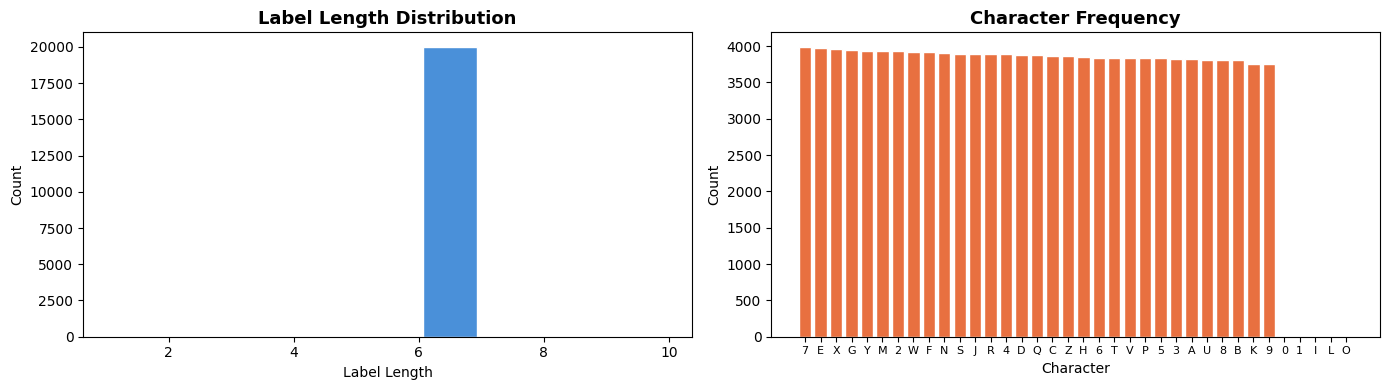

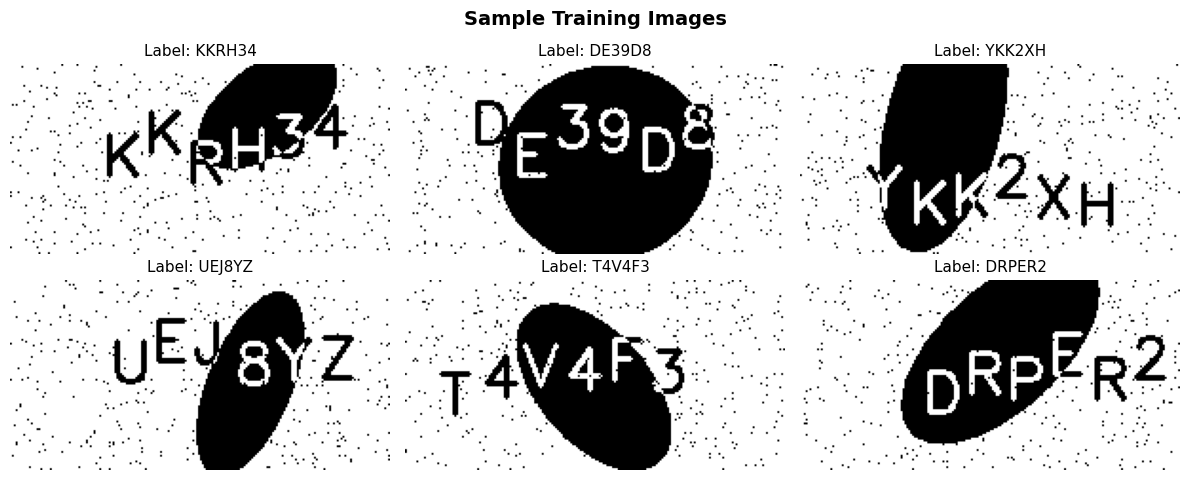


Dataset summary:
  Total samples  : 20000
  Label lengths  : min=6  max=9  mean=6.0
  Unique labels  : 19999


In [22]:
labels       = load_labels(TRAIN_CSV)
label_lengths = [len(v) for v in labels.values()]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# (a) Label length distribution
axes[0].hist(label_lengths, bins=range(1, max(label_lengths) + 2),
             color="#4A90D9", edgecolor="white", rwidth=0.85)
axes[0].set_title("Label Length Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Label Length")
axes[0].set_ylabel("Count")

# (b) Character frequency — how often does each character appear?
all_chars  = "".join(labels.values())
char_freq  = {ch: all_chars.count(ch) for ch in CHARS}
sorted_chars = sorted(char_freq.items(), key=lambda x: -x[1])
axes[1].bar([c for c, _ in sorted_chars], [f for _, f in sorted_chars],
            color="#E87040", edgecolor="white")
axes[1].set_title("Character Frequency", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Character")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", labelsize=8)

plt.tight_layout()
plt.show()

# (c) Show sample images with their labels
img_files = list(Path(TRAIN_IMG_DIR).glob("*.png"))[:6]
fig2, img_axes = plt.subplots(2, 3, figsize=(12, 5))
for ax, fpath in zip(img_axes.ravel(), img_files):
    img = Image.open(fpath).convert("L")
    lbl = labels.get(fpath.name, "?")
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {lbl}", fontsize=11)
    ax.axis("off")
fig2.suptitle("Sample Training Images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nDataset summary:")
print(f"  Total samples  : {len(labels)}")
print(f"  Label lengths  : min={min(label_lengths)}  max={max(label_lengths)}  mean={np.mean(label_lengths):.1f}")
print(f"  Unique labels  : {len(set(labels.values()))}")


## 8. Model Architecture — CRNN

**CRNN = Convolutional Recurrent Neural Network**

The model has three stages:

```
Input image (B, 1, 32, 128)
        │
        ▼
  ┌─────────────────────┐
  │  CNN Backbone       │  Extracts visual features. Height shrinks to 1.
  │  (conv + residual)  │  Output: (B, 512, 1, T')
  └─────────────────────┘
        │  squeeze + permute → (T', B, 512)
        ▼
  ┌─────────────────────┐
  │  Bidirectional LSTM │  Reads the feature columns left-to-right AND
  │  (2 layers)         │  right-to-left to capture context.
  └─────────────────────┘  Output: (T', B, 512)
        │
        ▼
  ┌─────────────────────┐
  │  Linear + Softmax   │  Converts to character probabilities.
  └─────────────────────┘  Output: (T', B, 37)
        │
        ▼
  CTC Loss  /  Greedy Decode
```

**T'** is the number of time steps output by the CNN — it must be ≥ the longest label in the dataset.


In [23]:
# ── Building block 1: Conv → BatchNorm → ReLU ──────────────────────────────
class ConvBnRelu(nn.Module):
    """A standard convolution block: Conv2d → BatchNorm2d → ReLU."""
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, pad=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, stride, pad, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


# ── Building block 2: Residual block ───────────────────────────────────────
class ResidualBlock(nn.Module):
    """
    Residual (skip-connection) block.
    Output = ReLU( conv(conv(x)) + x )
    The skip connection helps gradients flow during training.
    """
    def __init__(self, channels):
        super().__init__()
        self.conv1 = ConvBnRelu(channels, channels)
        self.conv2 = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.conv2(self.conv1(x)) + x)   # add skip connection


# ── CNN Backbone ────────────────────────────────────────────────────────────
class CRNNBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            ConvBnRelu(1, 64),
            nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 1), padding=(0, 1)),

            ConvBnRelu(64, 128),
            nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 1), padding=(0, 1)),

            ConvBnRelu(128, 256),
            ResidualBlock(256),
            nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 1), padding=(0, 1)),

            ConvBnRelu(256, 512),
            ResidualBlock(512),
            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=(0, 0)),

            ConvBnRelu(512, 512, kernel=(2, 1), stride=1, pad=0),
        )
        # ← ADDED: guarantees height=1 regardless of rounding in pooling stages
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, None))

    def forward(self, x):
        x = self.cnn(x)
        x = self.adaptive_pool(x)   # force (B, 512, 1, T') no matter what
        return x

# ── Full CRNN ───────────────────────────────────────────────────────────────
class CRNN(nn.Module):
    """
    Complete CRNN model: CNN → BiLSTM → Linear → log_softmax.

    Args:
        num_classes : vocabulary size (number of characters + CTC blank)
        hidden_size : BiLSTM hidden units per direction
        num_layers  : number of stacked BiLSTM layers
        dropout     : dropout between LSTM layers (regularisation)
    """
    def __init__(self, num_classes=NUM_CLASSES, hidden_size=HIDDEN_SIZE,
                 num_layers=NUM_LSTM_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.cnn = CRNNBackbone()

        self.rnn = nn.LSTM(
            input_size    = 512,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            dropout       = dropout if num_layers > 1 else 0.0,
            bidirectional = True,    # reads sequence both ways
            batch_first   = False,   # expects (T, B, features)
        )
        self.fc          = nn.Linear(hidden_size * 2, num_classes)
        self.log_softmax = nn.LogSoftmax(dim=2)

        self._init_weights()

    def _init_weights(self):
        """Initialise weights with standard strategies for each layer type."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # x: (B, 1, H, W)
        feat = self.cnn(x)            # (B, 512, 1, T')
        B, C, H, T = feat.shape
        assert H == 1, f"Height should be 1 after CNN, got {H}"

        feat = feat.squeeze(2)        # drop the H=1 dim → (B, 512, T')
        feat = feat.permute(2, 0, 1)  # → (T', B, 512)  — LSTM expects time first

        out, _ = self.rnn(feat)       # (T', B, hidden*2)
        out    = self.fc(out)         # (T', B, num_classes)
        return self.log_softmax(out)  # log-probabilities

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# ── Instantiate the model ───────────────────────────────────────────────────
model = CRNN(
    num_classes  = NUM_CLASSES,
    hidden_size  = HIDDEN_SIZE,
    num_layers   = NUM_LSTM_LAYERS,
    dropout      = DROPOUT,
).to(DEVICE)

print(model)
print(f"\nTotal trainable parameters: {model.count_parameters():,}")

# Quick shape check — pass a dummy batch through and print the output shape
dummy = torch.randn(2, 1, IMG_HEIGHT, IMG_WIDTH).to(DEVICE)
out   = model(dummy)
print(f"\nShape check: input {tuple(dummy.shape)} → output {tuple(out.shape)}")
print(f"Time steps T' = {out.shape[0]}  (must be ≥ max label length in the dataset)")


CRNN(
  (cnn): CRNNBackbone(
    (cnn): Sequential(
      (0): ConvBnRelu(
        (block): Sequential(
          (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
      )
      (1): MaxPool2d(kernel_size=(2, 2), stride=(2, 1), padding=(0, 1), dilation=1, ceil_mode=False)
      (2): ConvBnRelu(
        (block): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
      )
      (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 1), padding=(0, 1), dilation=1, ceil_mode=False)
      (4): ConvBnRelu(
        (block): Sequential(
          (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1):

## 9. Loss Function — CTC

**CTC (Connectionist Temporal Classification)** lets the model output a sequence of character probabilities for each time step without needing to know exactly where each character starts and ends in the image.

It sums the probability of every valid alignment between the output sequence and the target label, then maximises that sum. In practice this means:
- The model is free to output blanks between characters
- Repeated characters are automatically handled

`zero_infinity=True` prevents the loss from becoming NaN in edge cases where the target is longer than the model output.


In [24]:
class CTCLossWrapper(nn.Module):
    """
    Wraps PyTorch's CTCLoss and automatically computes input_lengths.

    input_lengths tells CTC how many time steps each sequence in the batch has.
    Since all images are the same size, T' is the same for every sample.
    """
    def __init__(self):
        super().__init__()
        self.ctc = nn.CTCLoss(blank=BLANK_IDX, reduction="mean", zero_infinity=True)

    def forward(self, log_probs, targets, target_lengths):
        """
        Args:
            log_probs      : (T, B, C)  log-probabilities from the model
            targets        : (total_chars,) flat concatenated label tensor
            target_lengths : (B,) number of characters in each label
        """
        T, B, _ = log_probs.shape
        # Every sequence in the batch has the same T time steps
        input_lengths = torch.full((B,), T, dtype=torch.long, device=log_probs.device)
        return self.ctc(log_probs, targets, input_lengths, target_lengths)


criterion = CTCLossWrapper().to(DEVICE)
print("CTC loss ready ✓")


CTC loss ready ✓


## 10. Evaluation Metric — Character Error Rate (CER)

Character Error Rate (CER) is a standard evaluation metric for OCR systems that quantifies the similarity between predicted text and the ground-truth label. It is calculated by dividing the Levenshtein (edit) distance between the prediction and target by the length of the target text. A CER of 0 indicates a perfect prediction, while higher values correspond to increasing numbers of character insertions, deletions, and substitutions. The edit distance is computed using a dynamic programming approach, enabling an accurate measurement of character-level recognition errors.



In [25]:
def levenshtein_distance(s1: str, s2: str) -> int:
    """
    Compute the minimum number of single-character edits (insert, delete, substitute)
    needed to change s1 into s2.  Uses O(n) space dynamic programming.
    """
    m, n = len(s1), len(s2)
    dp = list(range(n + 1))   # dp[j] = edit distance for s1[:0] vs s2[:j]
    for i in range(1, m + 1):
        prev = dp[0]
        dp[0] = i
        for j in range(1, n + 1):
            temp = dp[j]
            if s1[i - 1] == s2[j - 1]:
                dp[j] = prev             # characters match — no edit needed
            else:
                dp[j] = 1 + min(prev, dp[j], dp[j - 1])  # sub / del / ins
            prev = temp
    return dp[n]


def character_error_rate(predictions: list, targets: list) -> float:
    """
    Mean CER over a list of (prediction, target) string pairs.
    Returns a float in [0, ∞).  Lower is better.
    """
    total_dist = 0
    total_len  = 0
    for pred, tgt in zip(predictions, targets):
        total_dist += levenshtein_distance(pred, tgt)
        total_len  += max(len(tgt), 1)          # avoid division by zero
    return total_dist / total_len if total_len > 0 else 0.0


# Quick tests to verify the function works correctly
print("CER tests:")
print(f"  Perfect match   : {character_error_rate(['AXU323'], ['AXU323']):.4f}  (expect 0.0)")
print(f"  All wrong chars : {character_error_rate(['AXUAAA'], ['AXU323']):.4f}")
print(f"  Empty prediction: {character_error_rate([''],       ['AXU323']):.4f}  (expect 1.0)")
print(f"  Half correct    : {character_error_rate(['AXU'],    ['AXU323']):.4f}")


CER tests:
  Perfect match   : 0.0000  (expect 0.0)
  All wrong chars : 0.5000
  Empty prediction: 1.0000  (expect 1.0)
  Half correct    : 0.5000


## 11. Training Loop

The training loop runs for up to `NUM_EPOCHS` epochs.  
Each epoch:
1. **Train** — forward pass, compute CTC loss, backprop, update weights
2. **Validate** — forward pass only (no gradient updates), compute val CER

**Early stopping:** if val CER doesn't improve for `PATIENCE` consecutive epochs, training stops.  
**Checkpoint:** every time val CER improves, the model weights are saved to disk.  
**Gradient clipping:** caps gradient norms at 5.0 to prevent exploding gradients (common with RNNs).


In [26]:
print("train_loader" in globals())
print("val_loader" in globals())

True
True


In [28]:
# ============================================================
# Show Ground Truth vs Predicted
# ============================================================

model.eval()

n_samples = 20   # how many examples to display

shown = 0

with torch.no_grad():

    for images, targets, target_lengths in val_loader:

        images = images.to(DEVICE)

        log_probs = model(images)
        preds = batch_decode(log_probs)

        offset = 0

        for i, tlen in enumerate(target_lengths):

            tlen = int(tlen)

            gt = "".join(
                IDX2CHAR[int(x)]
                for x in targets[offset:offset+tlen]
            )

            offset += tlen

            pred = preds[i]

            status = "✓" if pred == gt else "✗"

            print(f"{status} GT: {gt:<12} | Pred: {pred}")

            shown += 1

            if shown >= n_samples:
                break

        if shown >= n_samples:
            break

✓ GT: Q23S7G       | Pred: Q23S7G
✓ GT: V9F987       | Pred: V9F987
✓ GT: BSD52X       | Pred: BSD52X
✓ GT: A2AT84       | Pred: A2AT84
✓ GT: WYH494       | Pred: WYH494
✓ GT: GAXNEH       | Pred: GAXNEH
✓ GT: 4JPZHH       | Pred: 4JPZHH
✓ GT: H5N9QN       | Pred: H5N9QN
✓ GT: RDV2BH       | Pred: RDV2BH
✓ GT: WKDBJD       | Pred: WKDBJD
✓ GT: T4FUR5       | Pred: T4FUR5
✓ GT: CT22Y8       | Pred: CT22Y8
✓ GT: 35C6Q5       | Pred: 35C6Q5
✓ GT: ZBP22B       | Pred: ZBP22B
✓ GT: UE8MHS       | Pred: UE8MHS
✓ GT: P9N9BB       | Pred: P9N9BB
✓ GT: HYE653       | Pred: HYE653
✓ GT: 6FVE5Y       | Pred: 6FVE5Y
✓ GT: 4NT4JS       | Pred: 4NT4JS
✓ GT: N9Q83R       | Pred: N9Q83R


## 12. Training Curves

Plotting loss and CER over epochs helps diagnose problems:
- **Both train and val loss decreasing** → training is working
- **Train loss low but val loss high** → overfitting (model memorised training data)
- **Both losses plateau early** → learning rate might be too low or model too small


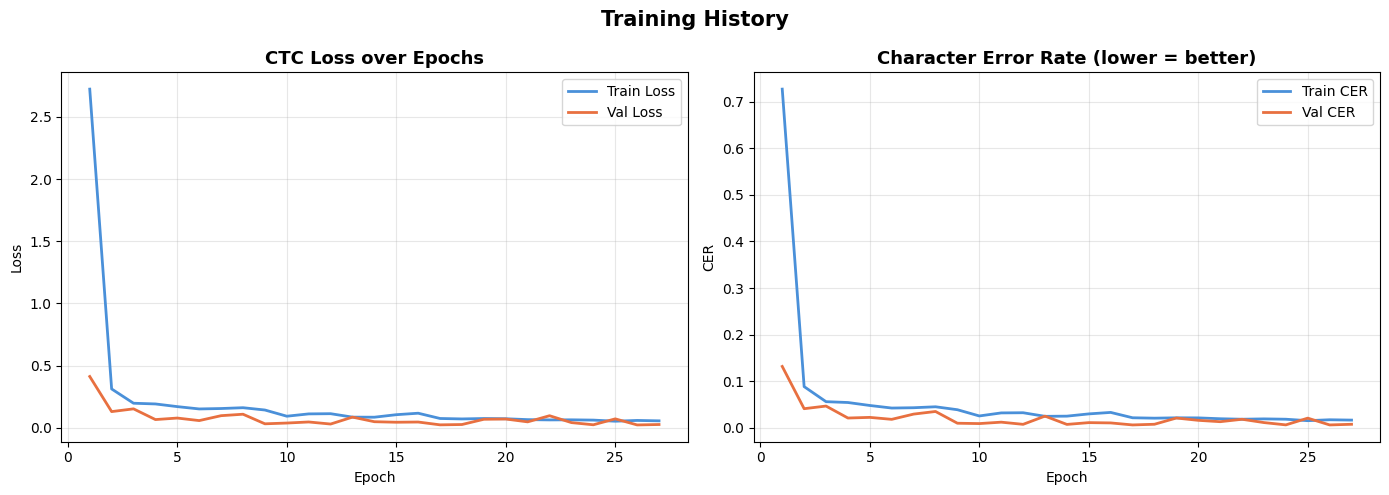

Saved → outputs/training_curves.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ep = range(1, len(history["train_loss"]) + 1)

# Left: CTC Loss
axes[0].plot(ep, history["train_loss"], label="Train Loss", color="#4A90D9", lw=2)
axes[0].plot(ep, history["val_loss"],   label="Val Loss",   color="#E87040", lw=2)
axes[0].set_title("CTC Loss over Epochs", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: Character Error Rate
axes[1].plot(ep, history["train_cer"], label="Train CER", color="#4A90D9", lw=2)
axes[1].plot(ep, history["val_cer"],   label="Val CER",   color="#E87040", lw=2)
axes[1].set_title("Character Error Rate (lower = better)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("CER")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Training History", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → outputs/training_curves.png")


## 13. Load Best Checkpoint & Final Evaluation

We reload the model weights from the checkpoint that had the lowest val CER during training, then do a final evaluation pass on the validation set and visualise some predictions.

Green title = correct prediction, Red title = wrong prediction.


Loaded checkpoint from epoch 17  |  Val CER: 0.0058


Validation:   0%|          | 0/94 [00:00<?, ?it/s]


Final Validation CER: 0.0058


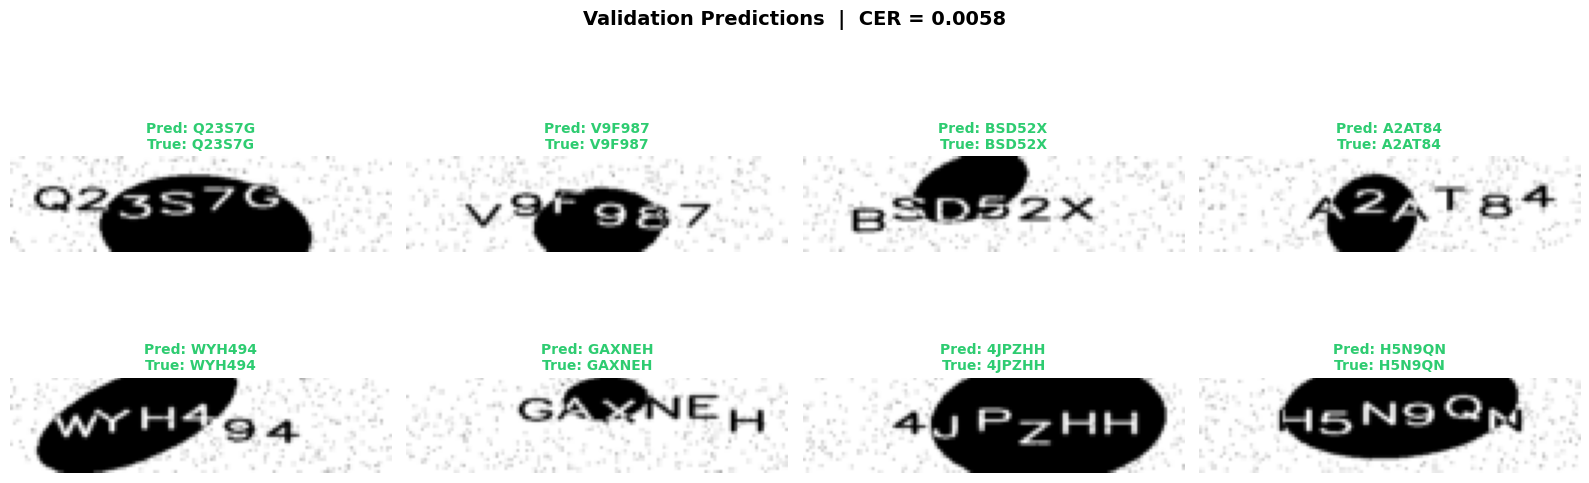

In [30]:
# ── Load the best saved checkpoint ─────────────────────────────────────────
checkpoint = torch.load("outputs/best_model.pt", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
print(f"Loaded checkpoint from epoch {checkpoint['epoch']}  |  Val CER: {checkpoint['val_cer']:.4f}")

# ── Full validation pass ────────────────────────────────────────────────────
_, final_cer, _ = run_epoch(model, val_loader, criterion, optimizer=None, is_train=False)
print(f"\nFinal Validation CER: {final_cer:.4f}")

# ── Visual inspection — show predictions vs ground truth ───────────────────
model.eval()
batch_imgs, batch_targets, batch_tgt_lens = next(iter(val_loader))
batch_imgs = batch_imgs.to(DEVICE)

with torch.no_grad():
    log_probs = model(batch_imgs)

predictions = batch_decode(log_probs)

# Reconstruct ground truth strings from the flat target tensor
target_strings = []
offset = 0
for tlen in batch_tgt_lens.numpy():
    tlen  = int(tlen)
    t_str = "".join(IDX2CHAR.get(int(i), "") for i in batch_targets[offset:offset + tlen])
    target_strings.append(t_str)
    offset += tlen

# Plot the first 8 images with their predictions
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for i, ax in enumerate(axes.ravel()):
    img_np  = batch_imgs[i, 0].cpu().numpy()
    img_np  = (img_np * 0.5 + 0.5)   # undo normalisation → back to [0, 1]
    correct = predictions[i] == target_strings[i]
    color   = "#2ecc71" if correct else "#e74c3c"   # green = correct, red = wrong
    ax.imshow(img_np, cmap="gray")
    ax.set_title(f"Pred: {predictions[i]}\nTrue: {target_strings[i]}",
                 fontsize=10, color=color, fontweight="bold")
    ax.axis("off")
fig.suptitle(f"Validation Predictions  |  CER = {final_cer:.4f}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/val_predictions.png", dpi=120, bbox_inches="tight")
plt.show()


## 14. Test Inference & Submission Generation

Run the trained model on all test images and save the predictions to a CSV file.  
The CSV has two columns: `image` (filename) and `prediction` (decoded text).


In [31]:
def generate_submission(model, test_loader, out_path="outputs/submission.csv"):
    """
    Run inference on all test images and write predictions to a CSV file.
    Returns the resulting DataFrame.
    """
    model.eval()
    results = []

    with torch.no_grad():
        for images, fnames in tqdm(test_loader, desc="Running inference"):
            images    = images.to(DEVICE)
            log_probs = model(images)           # (T', B, C)
            preds     = batch_decode(log_probs)
            for fname, pred in zip(fnames, preds):
                results.append({"image": fname, "prediction": pred})

    df = pd.DataFrame(results)
    # Sort by the numeric part of the filename (e.g. 1.png < 2.png < 10.png)
    df["_sort"] = df["image"].apply(lambda x: int(re.sub(r"\D", "", x) or 0))
    df = df.sort_values("_sort").drop(columns=["_sort"]).reset_index(drop=True)
    df.to_csv(out_path, index=False)
    print(f"Saved {len(df)} predictions → {out_path}")
    return df


sub_df = generate_submission(model, test_loader)
print("\nFirst 10 predictions:")
print(sub_df.head(10).to_string(index=False))


Running inference:   0%|          | 0/157 [00:00<?, ?it/s]

Saved 5000 predictions → outputs/submission.csv

First 10 predictions:
     image prediction
test-0.png     QVTQ8A
test-1.png     7PSW9D
test-2.png     WJ2WNY
test-3.png     RFHJD4
test-4.png     K7ZUF2
test-5.png     CPMUBK
test-6.png     UZDRAW
test-7.png     2YDPJR
test-8.png     H5SG63
test-9.png     B2Z823


## 15. Rename Submission File




In [ ]:
import shutil


STUDENT_NAME  = "Mahek singh"       
ENROLL_NUMBER = "25117081"   
# ────────────────────────────────────────────────────────────────────────────

src  = Path("outputs/submission.csv")
dest = Path(f"outputs/submission_{STUDENT_NAME}_{ENROLL_NUMBER}.csv")
shutil.copy(src, dest)
print(f"Submission file ready: {dest}")
print("\nFirst 5 rows:")
print(pd.read_csv(dest).head().to_string(index=False))


Submission file ready: outputs/submission_Mahek singh_25117081.csv

First 5 rows:
     image prediction
test-0.png     QVTQ8A
test-1.png     7PSW9D
test-2.png     WJ2WNY
test-3.png     RFHJD4
test-4.png     K7ZUF2


## 16. Optional Enhancement — Beam Search Decoder

The **greedy decoder** simply picks the most likely character at each time step.  
**Beam search** keeps track of the top-K most likely sequences and often gives a lower CER.

- `beam_width=1` → equivalent to greedy decoding  
- `beam_width=5` → usually a good balance of quality vs speed

This implementation is pure Python (no extra dependencies).


In [37]:
def _log_add(a, b):
    """Numerically stable log(exp(a) + exp(b))."""
    import math

    if a == float("-inf"):
        return b
    if b == float("-inf"):
        return a

    if a > b:
        return a + math.log1p(math.exp(b - a))
    else:
        return b + math.log1p(math.exp(a - b))


def beam_search_decode(log_probs_np, beam_width=5):
    """
    CTC Beam Search Decoder

    Args:
        log_probs_np: numpy array of shape (T, C)
        beam_width: beam size

    Returns:
        decoded string
    """
    from collections import defaultdict

    NEG_INF = float("-inf")
    T, C = log_probs_np.shape

    # prefix -> (prob_blank, prob_non_blank)
    beams = {(): (0.0, NEG_INF)}

    for t in range(T):

        new_beams = defaultdict(lambda: (NEG_INF, NEG_INF))

        for prefix, (pb, pnb) in beams.items():

            for c in range(C):

                lp = float(log_probs_np[t, c])

                # Blank
                if c == BLANK_IDX:

                    new_pb = _log_add(
                        new_beams[prefix][0],
                        _log_add(
                            _log_add(pb, lp),
                            _log_add(pnb, lp)
                        )
                    )

                    new_beams[prefix] = (
                        new_pb,
                        new_beams[prefix][1]
                    )

                # Non-blank
                else:

                    new_prefix = prefix + (c,)

                    new_pnb_val = _log_add(pb, lp)

                    if not (prefix and prefix[-1] == c):
                        new_pnb_val = _log_add(
                            new_pnb_val,
                            _log_add(pnb, lp)
                        )

                    new_pnb = _log_add(
                        new_beams[new_prefix][1],
                        new_pnb_val
                    )

                    new_beams[new_prefix] = (
                        new_beams[new_prefix][0],
                        new_pnb
                    )

        # Keep top beams
        beams = dict(
            sorted(
                new_beams.items(),
                key=lambda kv: _log_add(kv[1][0], kv[1][1]),
                reverse=True
            )[:beam_width]
        )

    best_prefix = max(
        beams.items(),
        key=lambda kv: _log_add(kv[1][0], kv[1][1])
    )[0]

    return "".join(
        IDX2CHAR.get(c, "")
        for c in best_prefix
    )

In [38]:
test_lp = torch.randn(20, NUM_CLASSES).log_softmax(dim=1).numpy()

result = beam_search_decode(
    test_lp,
    beam_width=5
)

print(result)

4PWIOYD7Y2MCMIF47SO


## 17. Summary & Conclusions

### What we built
- A **CRNN with CTC loss** for recognising text in distorted grayscale images
- A **custom residual CNN backbone** that collapses image height to 1 while keeping the width as a sequence
- A **Bidirectional LSTM** to capture context across the character sequence in both directions
- **Greedy and beam search decoders** for converting model output to text

### Key design choices

| Choice | Reason |
|---|---|
| IMG_HEIGHT=32, IMG_WIDTH=128 | Fixed size allows batching; width preserves sequence info |
| Augmentation (blur, noise, affine) | Makes model robust to the competition distortions |
| CosineAnnealingLR | Smoothly decays LR to help escape local minima |
| Early stopping | Stops training when the model starts overfitting |
| Gradient clipping (max_norm=5) | Prevents exploding gradients common in RNNs |

### Ideas for further improvement
- **TrOCR / ViT backbone** — transformer vision encoders often outperform CNN backbones on distorted text
- **Ensemble** — average predictions from 3–5 models trained with different seeds
- **Beam search with LM** — rescore beam search hypotheses with a character n-gram language model
- **Higher resolution** — try IMG_WIDTH=256 if GPU memory allows
